# 🩺 Dự án Chẩn đoán Bệnh Tiểu Đường — Notebook 2
## XGBoost Training · Probability Calibration · SHAP · Rule-based Advice
---
### Nội dung Notebook:
1. Load dữ liệu đã preprocessed
2. Huấn luyện XGBoost (Hyperparameter Tuning)
3. Đánh giá mô hình
4. Probability Calibration (Platt Scaling / Isotonic)
5. Phân tầng rủi ro: Low / Medium / High
6. SHAP Analysis — Yếu tố ảnh hưởng
7. Rule-based Recommendation Engine
8. Demo dự đoán cuối cùng
9. Lưu mô hình


## ⚙️ 0. Cài đặt thư viện

In [1]:
%pip install xgboost scikit-learn shap matplotlib seaborn pandas numpy --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 📦 1. Import thư viện

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import warnings, os, json, pickle
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      GridSearchCV, RandomizedSearchCV)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (accuracy_score, classification_report,
                              roc_auc_score, confusion_matrix, f1_score,
                              recall_score, precision_score,
                              balanced_accuracy_score, brier_score_loss,
                              roc_curve, precision_recall_curve)
from xgboost import XGBClassifier, plot_importance

# ─── Cấu hình ───
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                      'axes.titlesize': 13, 'axes.labelsize': 11})
sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42

print("✅ Tất cả thư viện đã import thành công!")


d:\PYL_3116\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Tất cả thư viện đã import thành công!


## 📂 2. Load dữ liệu đã Preprocessed

In [3]:
# Load splits từ Notebook 1
DATA_DIR = './processed_data'

X_train = pd.read_csv(f'{DATA_DIR}/X_train.csv')
X_val   = pd.read_csv(f'{DATA_DIR}/X_val.csv')
X_test  = pd.read_csv(f'{DATA_DIR}/X_test.csv')
y_train = pd.read_csv(f'{DATA_DIR}/y_train.csv').squeeze()
y_val   = pd.read_csv(f'{DATA_DIR}/y_val.csv').squeeze()
y_test  = pd.read_csv(f'{DATA_DIR}/y_test.csv').squeeze()

with open(f'{DATA_DIR}/metadata.json') as f:
    meta = json.load(f)

FEATURES = meta['features']
TARGET   = meta['target']

print("✅ Dữ liệu đã load:")
print(f"   Train : {X_train.shape}  |  TĐ rate: {y_train.mean():.3f}")
print(f"   Val   : {X_val.shape}   |  TĐ rate: {y_val.mean():.3f}")
print(f"   Test  : {X_test.shape}  |  TĐ rate: {y_test.mean():.3f}")
print(f"   Features: {len(FEATURES)}")


✅ Dữ liệu đã load:
   Train : (49482, 28)  |  TĐ rate: 0.500
   Val   : (10606, 28)   |  TĐ rate: 0.500
   Test  : (10604, 28)  |  TĐ rate: 0.500
   Features: 28


## 🔧 3. Baseline XGBoost + Hyperparameter Tuning

In [4]:
# ─── 3.1 Baseline Model ───
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
SPW = neg / pos  # scale_pos_weight

baseline = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=SPW,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    n_jobs=-1
)

baseline.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

y_pred_base = baseline.predict(X_val)
y_prob_base = baseline.predict_proba(X_val)[:, 1]

print("=" * 55)
print("  BASELINE XGBoost — Validation Set")
print("=" * 55)
print(f"  Accuracy        : {accuracy_score(y_val, y_pred_base):.4f}")
print(f"  Balanced Acc    : {balanced_accuracy_score(y_val, y_pred_base):.4f}")
print(f"  ROC-AUC         : {roc_auc_score(y_val, y_prob_base):.4f}")
print(f"  F1-Score        : {f1_score(y_val, y_pred_base):.4f}")
print(f"  Recall (Sensitivity): {recall_score(y_val, y_pred_base):.4f}")
print(f"  Precision       : {precision_score(y_val, y_pred_base):.4f}")
print()
print(classification_report(y_val, y_pred_base,
                             target_names=['Không TĐ', 'Tiểu Đường']))


  BASELINE XGBoost — Validation Set
  Accuracy        : 0.7502
  Balanced Acc    : 0.7502
  ROC-AUC         : 0.8254
  F1-Score        : 0.7602
  Recall (Sensitivity): 0.7916
  Precision       : 0.7311

              precision    recall  f1-score   support

    Không TĐ       0.77      0.71      0.74      5303
  Tiểu Đường       0.73      0.79      0.76      5303

    accuracy                           0.75     10606
   macro avg       0.75      0.75      0.75     10606
weighted avg       0.75      0.75      0.75     10606



In [5]:
# ─── 3.2 Hyperparameter Tuning (RandomizedSearch) ───
# Nếu muốn skip và dùng baseline, set TUNE = False
TUNE = True

if TUNE:
    param_grid = {
        'n_estimators': [200, 300, 400, 500],
        'max_depth': [4, 5, 6, 7, 8],
        'learning_rate': [0.05, 0.08, 0.1, 0.15],
        'subsample': [0.7, 0.8, 0.9],
        'colsample_bytree': [0.7, 0.8, 0.9],
        'min_child_weight': [3, 5, 7, 10],
        'gamma': [0, 0.05, 0.1, 0.2],
        'reg_alpha': [0, 0.01, 0.1],
        'reg_lambda': [0.5, 1, 1.5],
    }

    base_for_tuning = XGBClassifier(
        scale_pos_weight=SPW,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        n_jobs=-1
    )

    cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    search = RandomizedSearchCV(
        base_for_tuning,
        param_distributions=param_grid,
        n_iter=50,           # Tăng lên 100+ nếu có thời gian
        scoring='roc_auc',
        cv=cv_strat,
        verbose=1,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    print("🔄 Đang tìm kiếm hyperparameters tốt nhất (50 iterations × 5-fold)...")
    print("   ⏳ Mất khoảng 5-15 phút...\n")

    search.fit(X_train, y_train)

    print(f"\n✅ Best ROC-AUC (CV): {search.best_score_:.4f}")
    print(f"   Best params: {search.best_params_}")
    best_params = search.best_params_

else:
    print("⚡ Dùng baseline params (TUNE=False)")
    best_params = {
        'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.08,
        'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 5,
        'gamma': 0.1, 'reg_alpha': 0.01, 'reg_lambda': 1.0
    }


🔄 Đang tìm kiếm hyperparameters tốt nhất (50 iterations × 5-fold)...
   ⏳ Mất khoảng 5-15 phút...

Fitting 5 folds for each of 50 candidates, totalling 250 fits

✅ Best ROC-AUC (CV): 0.8303
   Best params: {'subsample': 0.9, 'reg_lambda': 1.5, 'reg_alpha': 0.01, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.05, 'colsample_bytree': 0.7}


In [6]:
# ─── 3.3 Train Final Model với best params ───
final_model = XGBClassifier(
    **best_params,
    scale_pos_weight=SPW,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    n_jobs=-1
)

final_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50
)

print("\n✅ Final model đã được huấn luyện!")


[0]	validation_0-logloss:0.67914	validation_1-logloss:0.67912
[50]	validation_0-logloss:0.51138	validation_1-logloss:0.51153
[100]	validation_0-logloss:0.49842	validation_1-logloss:0.50160
[150]	validation_0-logloss:0.49410	validation_1-logloss:0.50003
[200]	validation_0-logloss:0.49150	validation_1-logloss:0.49951
[250]	validation_0-logloss:0.48923	validation_1-logloss:0.49947
[299]	validation_0-logloss:0.48732	validation_1-logloss:0.49967

✅ Final model đã được huấn luyện!


## 📊 4. Đánh giá Mô hình

In [7]:
# ─── 4.1 Metrics trên Val & Test ───
def evaluate_model(model, X, y, set_name='Val'):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    metrics = {
        'Accuracy':          accuracy_score(y, y_pred),
        'Balanced Accuracy': balanced_accuracy_score(y, y_pred),
        'ROC-AUC':           roc_auc_score(y, y_prob),
        'F1-Score':          f1_score(y, y_pred),
        'Recall':            recall_score(y, y_pred),
        'Precision':         precision_score(y, y_pred),
        'Brier Score':       brier_score_loss(y, y_prob),
    }

    print(f"\n{'='*50}")
    print(f"  📊 {set_name} Set Metrics")
    print(f"{'='*50}")
    for k, v in metrics.items():
        better = '↑' if k != 'Brier Score' else '↓'
        print(f"  {k:<22}: {v:.4f}  {better}")
    return metrics, y_pred, y_prob

print("🔍 Đánh giá trên Validation Set:")
val_metrics, y_val_pred, y_val_prob = evaluate_model(final_model, X_val, y_val, 'Validation')

print("\n🔍 Đánh giá trên Test Set (KHÔNG dùng để tuning):")
test_metrics, y_test_pred, y_test_prob = evaluate_model(final_model, X_test, y_test, 'Test')


🔍 Đánh giá trên Validation Set:

  📊 Validation Set Metrics
  Accuracy              : 0.7564  ↑
  Balanced Accuracy     : 0.7564  ↑
  ROC-AUC               : 0.8319  ↑
  F1-Score              : 0.7665  ↑
  Recall                : 0.7999  ↑
  Precision             : 0.7358  ↑
  Brier Score           : 0.1659  ↓

🔍 Đánh giá trên Test Set (KHÔNG dùng để tuning):

  📊 Test Set Metrics
  Accuracy              : 0.7554  ↑
  Balanced Accuracy     : 0.7554  ↑
  ROC-AUC               : 0.8330  ↑
  F1-Score              : 0.7664  ↑
  Recall                : 0.8025  ↑
  Precision             : 0.7334  ↑
  Brier Score           : 0.1653  ↓


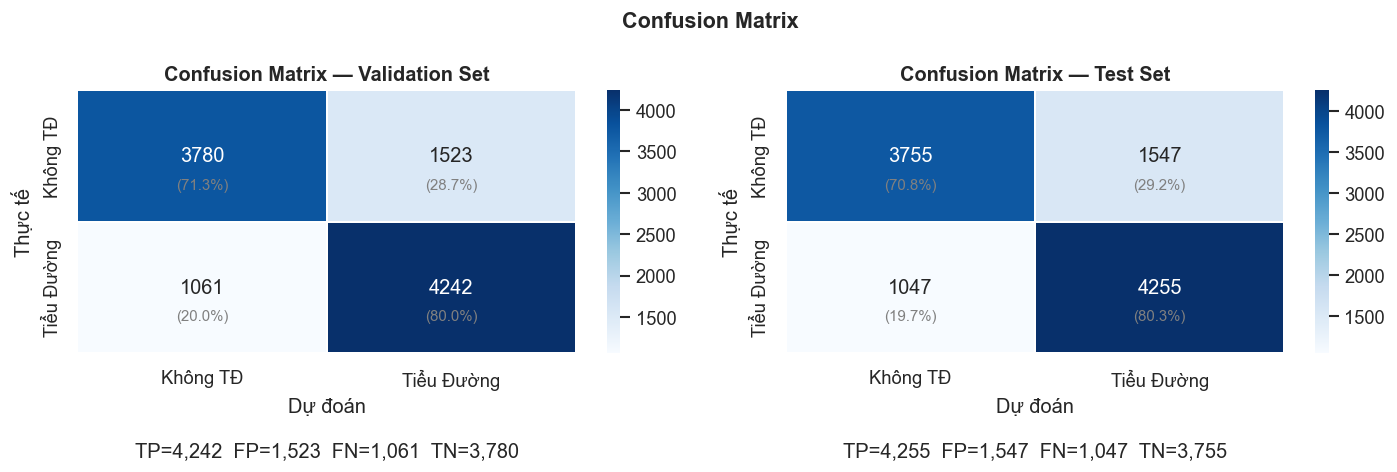

In [8]:
# ─── 4.2 Confusion Matrix ───
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_true, y_pred, title in [
        (axes[0], y_val,  y_val_pred,  'Validation Set'),
        (axes[1], y_test, y_test_pred, 'Test Set')]:

    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=['Không TĐ', 'Tiểu Đường'],
                yticklabels=['Không TĐ', 'Tiểu Đường'],
                linewidths=1, linecolor='white')

    # Thêm % vào từng ô
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.72, f'({cm_pct[i,j]:.1f}%)',
                     ha='center', va='center', fontsize=9, color='gray')

    ax.set_title(f'Confusion Matrix — {title}', fontweight='bold')
    ax.set_ylabel('Thực tế')
    ax.set_xlabel('Dự đoán')

    tn, fp, fn, tp = cm.ravel()
    ax.set_xlabel(f'Dự đoán\n\nTP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,}')

plt.suptitle('Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight', dpi=120)
plt.show()


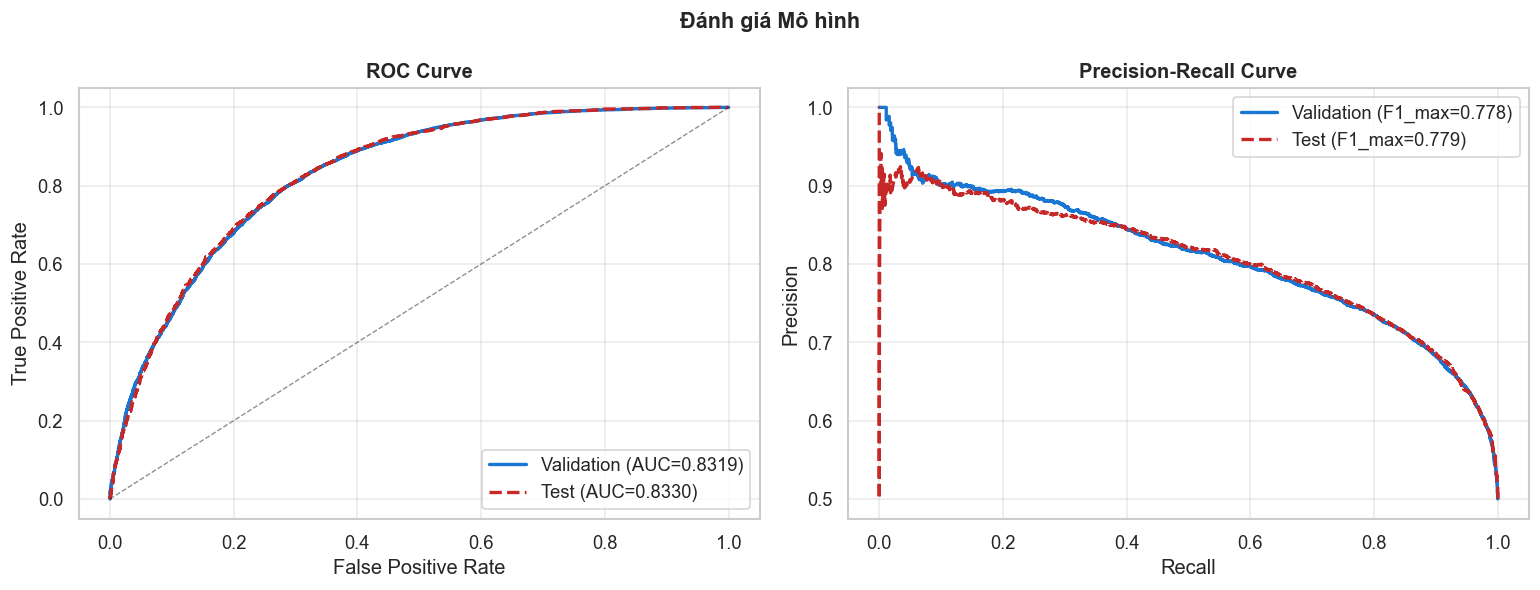

In [9]:
# ─── 4.3 ROC Curve & PR Curve ───
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC Curve
for X_, y_, label, color, ls in [
        (X_val,  y_val,  'Validation', '#1976D2', '-'),
        (X_test, y_test, 'Test',       '#C62828', '--')]:
    y_p = final_model.predict_proba(X_)[:, 1]
    fpr, tpr, _ = roc_curve(y_, y_p)
    auc = roc_auc_score(y_, y_p)
    axes[0].plot(fpr, tpr, color=color, linestyle=ls, linewidth=2,
                  label=f'{label} (AUC={auc:.4f})')

axes[0].plot([0,1],[0,1], 'k--', linewidth=0.8, alpha=0.5)
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()
axes[0].grid(alpha=0.4)

# PR Curve
for X_, y_, label, color, ls in [
        (X_val,  y_val,  'Validation', '#1976D2', '-'),
        (X_test, y_test, 'Test',       '#C62828', '--')]:
    y_p = final_model.predict_proba(X_)[:, 1]
    prec, rec, _ = precision_recall_curve(y_, y_p)
    f1_max = (2 * prec * rec / (prec + rec + 1e-8)).max()
    axes[1].plot(rec, prec, color=color, linestyle=ls, linewidth=2,
                  label=f'{label} (F1_max={f1_max:.3f})')

axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
axes[1].grid(alpha=0.4)

plt.suptitle('Đánh giá Mô hình', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_pr_curves.png', bbox_inches='tight', dpi=120)
plt.show()


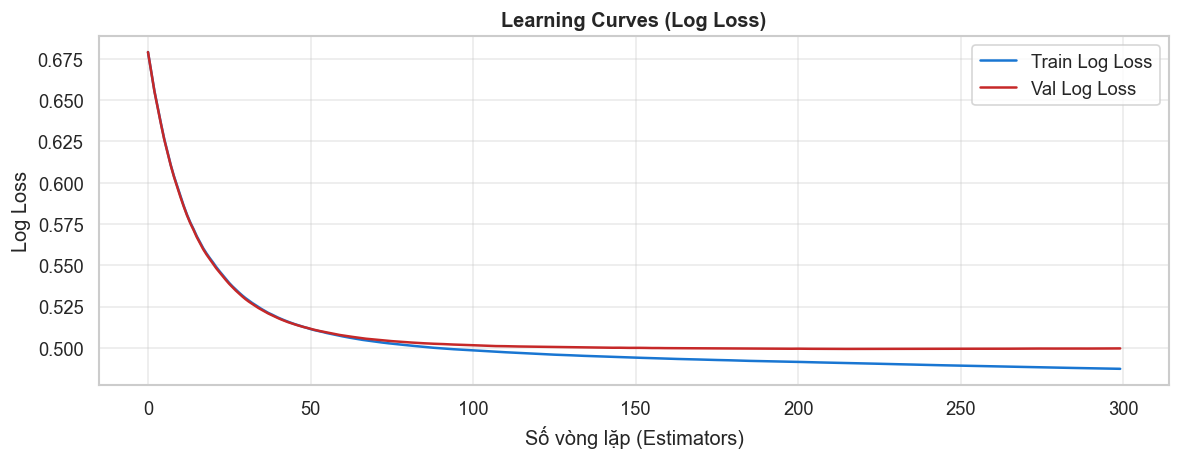

In [10]:
# ─── 4.4 Learning curves (Training history) ───
results = final_model.evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(epochs)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_axis, results['validation_0']['logloss'], label='Train Log Loss', color='#1976D2')
ax.plot(x_axis, results['validation_1']['logloss'], label='Val Log Loss',   color='#C62828')
ax.set_title('Learning Curves (Log Loss)', fontweight='bold')
ax.set_xlabel('Số vòng lặp (Estimators)')
ax.set_ylabel('Log Loss')
ax.legend()
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('learning_curves.png', bbox_inches='tight', dpi=120)
plt.show()


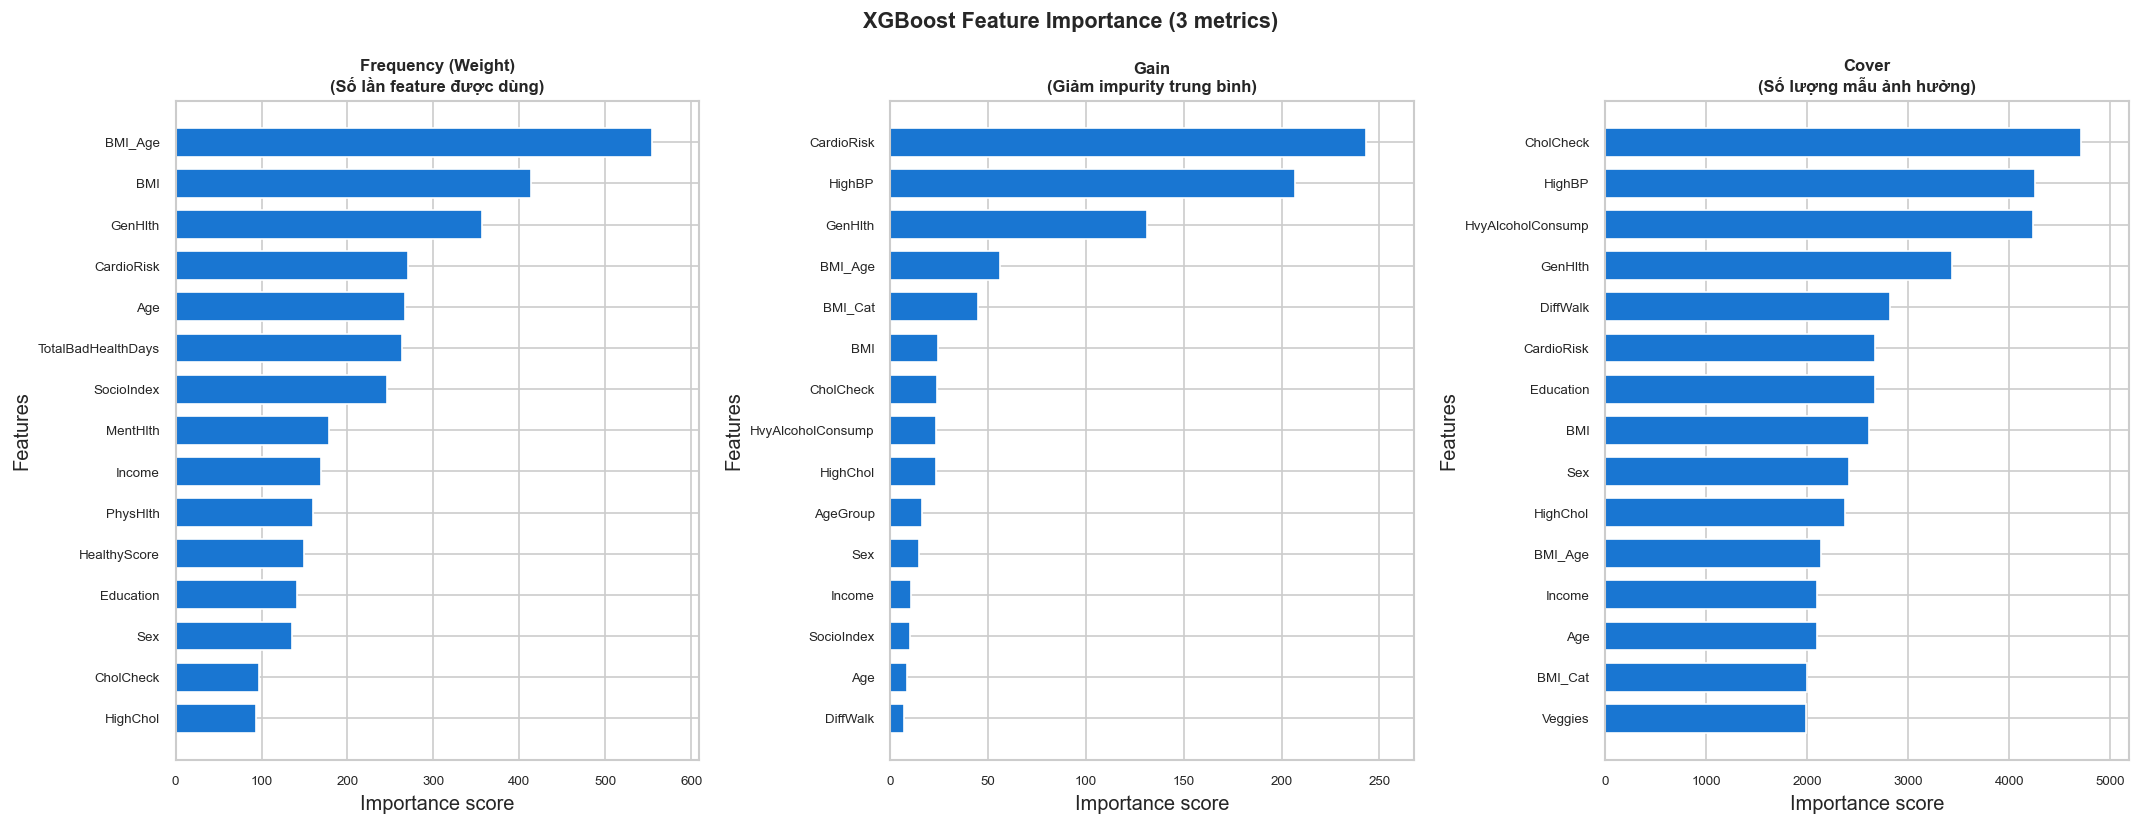

In [11]:
# ─── 4.5 XGBoost Feature Importance (Built-in) ───
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

importance_types = ['weight', 'gain', 'cover']
titles = ['Frequency (Weight)\n(Số lần feature được dùng)',
           'Gain\n(Giảm impurity trung bình)',
           'Cover\n(Số lượng mẫu ảnh hưởng)']

for ax, imp_type, title in zip(axes, importance_types, titles):
    plot_importance(final_model, ax=ax, importance_type=imp_type,
                     max_num_features=15, height=0.7,
                     color='#1976D2', show_values=False)
    ax.set_title(f'{title}', fontweight='bold', fontsize=10)
    ax.tick_params(labelsize=8)

plt.suptitle('XGBoost Feature Importance (3 metrics)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', bbox_inches='tight', dpi=120)
plt.show()


## 🎯 5. Probability Calibration

> **Vấn đề:** XGBoost có thể trả ra xác suất không phản ánh đúng thực tế.
> Ví dụ: model nói 70% nhưng thực tế chỉ 40% người có xác suất đó bị TĐ.
>
> **Giải pháp:** Calibration — điều chỉnh xác suất để phản ánh tần suất thực tế.
>
> **Phương pháp:**
> - `sigmoid` (Platt Scaling): phù hợp khi đường calibration gần tuyến tính
> - `isotonic`: phù hợp khi đường calibration phi tuyến, cần dữ liệu nhiều hơn


In [12]:
# === 5.1 Calibration ===
# sklearn >= 1.2 removed cv='prefit' from CalibratedClassifierCV.
# Solution: ManualCalibratedModel (mathematically equivalent).

from sklearn.calibration  import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic     import IsotonicRegression

class ManualCalibratedModel:
    def __init__(self, base_model, method='sigmoid'):
        self.base_model  = base_model
        self.method      = method
        self._calibrator = None

    def fit(self, X_cal, y_cal):
        raw = self.base_model.predict_proba(X_cal)[:, 1]
        if self.method == 'sigmoid':
            # Platt Scaling
            self._calibrator = LogisticRegression(
                solver='lbfgs', C=1e10, max_iter=1000)
            self._calibrator.fit(raw.reshape(-1, 1), y_cal)
        else:
            # Isotonic Regression
            self._calibrator = IsotonicRegression(out_of_bounds='clip')
            self._calibrator.fit(raw, y_cal)
        return self

    def predict_proba(self, X):
        raw = self.base_model.predict_proba(X)[:, 1]
        if self.method == 'sigmoid':
            cal = self._calibrator.predict_proba(raw.reshape(-1, 1))[:, 1]
        else:
            cal = np.clip(self._calibrator.predict(raw), 0, 1)
        return np.column_stack([1 - cal, cal])

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X)[:, 1] >= threshold).astype(int)


# Fit tren Validation Set
calibrated_sig = ManualCalibratedModel(final_model, method='sigmoid')
calibrated_iso = ManualCalibratedModel(final_model, method='isotonic')

calibrated_sig.fit(X_val, y_val)
calibrated_iso.fit(X_val, y_val)

print('Calibration hoan thanh!')
print('  Sigmoid  (Platt Scaling) : LogisticRegression(raw_probs)')
print('  Isotonic                 : IsotonicRegression(raw_probs)')
print()

models = {
    'XGBoost (Raw)':       final_model,
    'XGBoost + Sigmoid':   calibrated_sig,
    'XGBoost + Isotonic':  calibrated_iso,
}

print('=' * 65)
print('  Brier Score (thap hon = tot hon)')
print('=' * 65)
brier_scores = {}
for name, mdl in models.items():
    prob = mdl.predict_proba(X_test)[:, 1]
    bs   = brier_score_loss(y_test, prob)
    brier_scores[name] = bs
    print(f'  {name:<30}: {bs:.5f}')

best_method = min(brier_scores, key=brier_scores.get)
print(f'\n  Best method: {best_method}')


Calibration hoan thanh!
  Sigmoid  (Platt Scaling) : LogisticRegression(raw_probs)
  Isotonic                 : IsotonicRegression(raw_probs)

  Brier Score (thap hon = tot hon)
  XGBoost (Raw)                 : 0.16527
  XGBoost + Sigmoid             : 0.16610
  XGBoost + Isotonic            : 0.16561

  Best method: XGBoost (Raw)


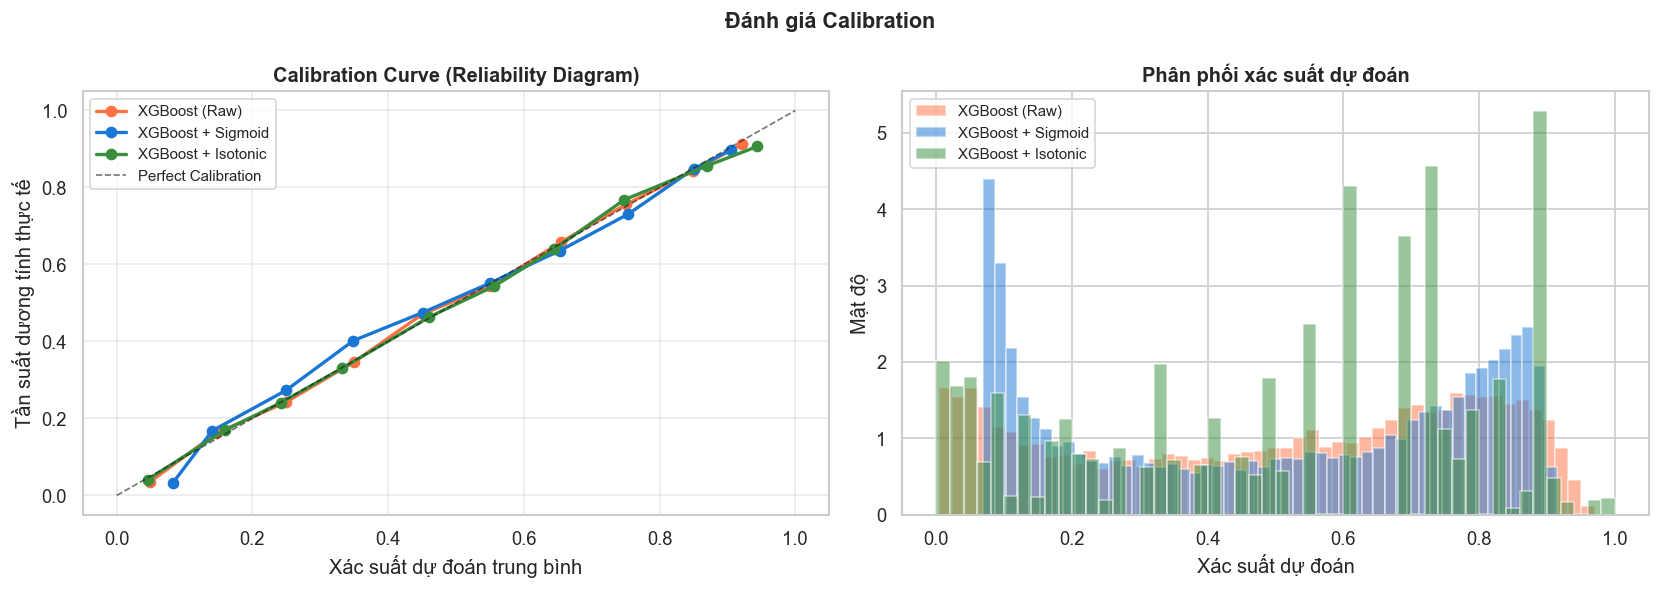

In [13]:
# ─── 5.2 Calibration Curve (Reliability Diagram) ───
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_cal = {'XGBoost (Raw)': '#FF7043',
               'XGBoost + Sigmoid': '#1976D2',
               'XGBoost + Isotonic': '#388E3C'}

for name, model in models.items():
    prob = model.predict_proba(X_test)[:, 1]
    fraction, mean_pred = calibration_curve(y_test, prob, n_bins=10)
    axes[0].plot(mean_pred, fraction, marker='o', linewidth=2,
                  label=name, color=colors_cal[name])

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.6, label='Perfect Calibration')
axes[0].set_title('Calibration Curve (Reliability Diagram)', fontweight='bold')
axes[0].set_xlabel('Xác suất dự đoán trung bình')
axes[0].set_ylabel('Tần suất dương tính thực tế')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.4)

# Probability histogram
for name, model in models.items():
    prob = model.predict_proba(X_test)[:, 1]
    axes[1].hist(prob, bins=50, alpha=0.5, density=True,
                  label=name, color=colors_cal[name])
axes[1].set_title('Phân phối xác suất dự đoán', fontweight='bold')
axes[1].set_xlabel('Xác suất dự đoán')
axes[1].set_ylabel('Mật độ')
axes[1].legend(fontsize=9)

plt.suptitle('Đánh giá Calibration', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('calibration_curves.png', bbox_inches='tight', dpi=120)
plt.show()


In [14]:
# ─── 5.3 Chọn model đã calibrated ───
# Chọn dựa trên Brier score tốt nhất
if brier_scores['XGBoost + Isotonic'] <= brier_scores['XGBoost + Sigmoid']:
    calibrated_model = calibrated_iso
    cal_method = 'Isotonic'
else:
    calibrated_model = calibrated_sig
    cal_method = 'Sigmoid (Platt)'

print(f"✅ Sử dụng calibration: {cal_method}")
print()

# Final metrics sau calibration
y_cal_pred = calibrated_model.predict(X_test)
y_cal_prob = calibrated_model.predict_proba(X_test)[:, 1]

print("=" * 50)
print("  FINAL MODEL METRICS (Test Set, After Calibration)")
print("=" * 50)
print(f"  Accuracy        : {accuracy_score(y_test, y_cal_pred):.4f}")
print(f"  Balanced Acc    : {balanced_accuracy_score(y_test, y_cal_pred):.4f}")
print(f"  ROC-AUC         : {roc_auc_score(y_test, y_cal_prob):.4f}")
print(f"  F1-Score        : {f1_score(y_test, y_cal_pred):.4f}")
print(f"  Recall          : {recall_score(y_test, y_cal_pred):.4f}")
print(f"  Precision       : {precision_score(y_test, y_cal_pred):.4f}")
print(f"  Brier Score     : {brier_score_loss(y_test, y_cal_prob):.5f}")


✅ Sử dụng calibration: Isotonic

  FINAL MODEL METRICS (Test Set, After Calibration)
  Accuracy        : 0.7554
  Balanced Acc    : 0.7554
  ROC-AUC         : 0.8327
  F1-Score        : 0.7664
  Recall          : 0.8025
  Precision       : 0.7334
  Brier Score     : 0.16561


## 🚦 6. Phân tầng Rủi ro: Low / Medium / High

> Dựa trên xác suất đã calibrated, phân loại thành 3 mức rủi ro:
> - 🟢 **LOW** (< 20%): Nguy cơ thấp — Duy trì lối sống lành mạnh
> - 🟡 **MEDIUM** (20-50%): Nguy cơ trung bình — Nên kiểm tra sức khỏe
> - 🔴 **HIGH** (≥ 50%): Nguy cơ cao — Cần khám bác sĩ ngay


In [15]:
# ─── 6.1 Định nghĩa ngưỡng rủi ro ───
THRESHOLD_LOW    = 0.20   # < 20%  → Low
THRESHOLD_MEDIUM = 0.50   # 20-50% → Medium
                           # ≥ 50%  → High

def get_risk_level(prob):
    """Phân loại mức độ rủi ro từ xác suất calibrated"""
    if prob < THRESHOLD_LOW:
        return 'LOW', '🟢', 'Thấp'
    elif prob < THRESHOLD_MEDIUM:
        return 'MEDIUM', '🟡', 'Trung bình'
    else:
        return 'HIGH', '🔴', 'Cao'

# Áp dụng cho test set
risk_levels = [get_risk_level(p)[0] for p in y_cal_prob]
risk_df = pd.DataFrame({
    'prob': y_cal_prob,
    'risk_level': risk_levels,
    'true_label': y_test.values
})

print("📊 Phân phối mức rủi ro trong Test Set:")
print()
for level, emoji, vn in [('LOW','🟢','Thấp'), ('MEDIUM','🟡','Trung bình'), ('HIGH','🔴','Cao')]:
    subset = risk_df[risk_df['risk_level'] == level]
    n = len(subset)
    actual_td_rate = subset['true_label'].mean() * 100
    print(f"  {emoji} {level:<8} ({vn:<12}): {n:5,} mẫu ({n/len(risk_df)*100:.1f}%)")
    print(f"           Tỷ lệ TĐ thực tế: {actual_td_rate:.1f}%  |  Prob range: [{subset['prob'].min():.3f}, {subset['prob'].max():.3f}]")
    print()


📊 Phân phối mức rủi ro trong Test Set:

  🟢 LOW      (Thấp        ): 2,494 mẫu (23.5%)
           Tỷ lệ TĐ thực tế: 8.5%  |  Prob range: [0.000, 0.190]

  🟡 MEDIUM   (Trung bình  ): 2,308 mẫu (21.8%)
           Tỷ lệ TĐ thực tế: 36.2%  |  Prob range: [0.206, 0.492]

  🔴 HIGH     (Cao         ): 5,802 mẫu (54.7%)
           Tỷ lệ TĐ thực tế: 73.3%  |  Prob range: [0.500, 1.000]



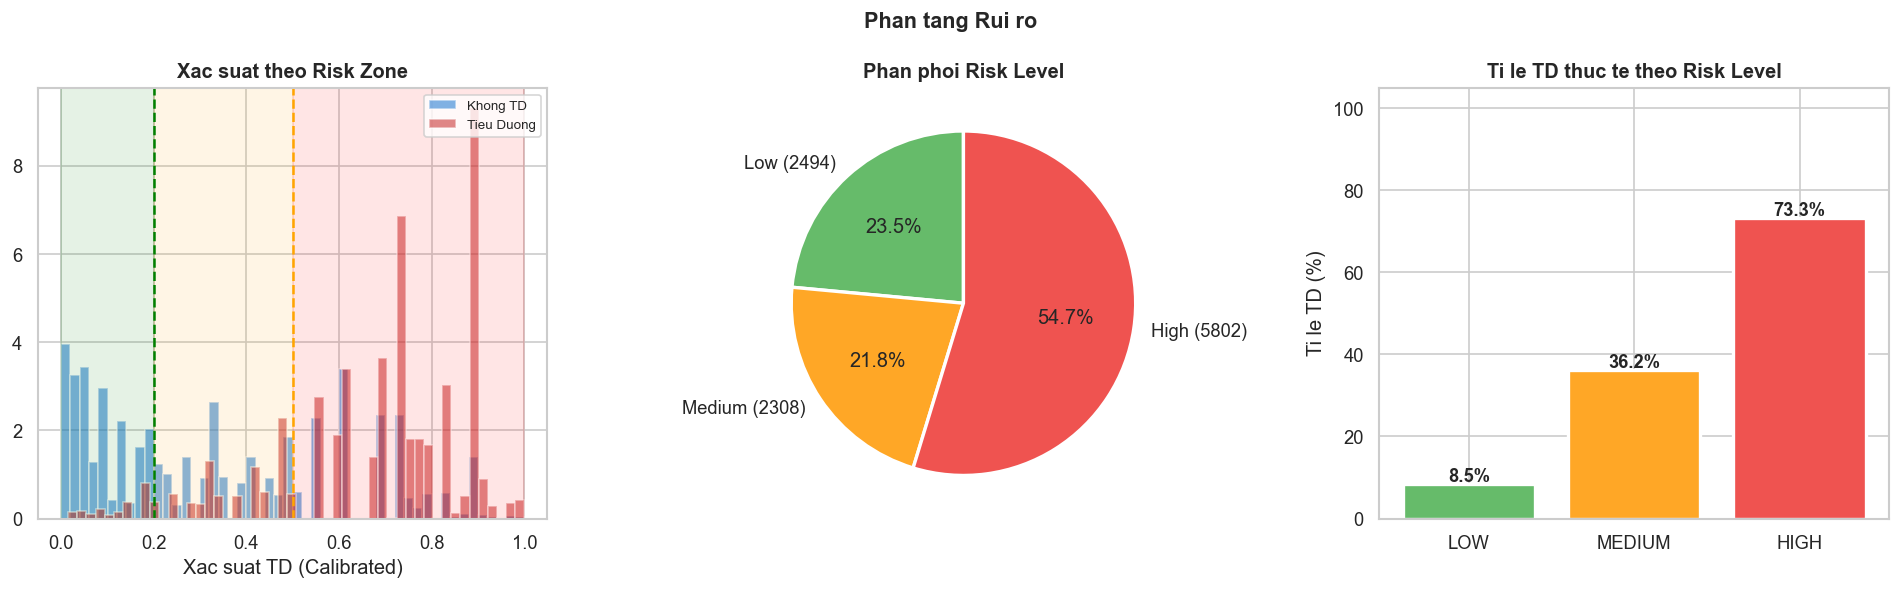

In [16]:
# --- 6.2 Visualize phan phoi rui ro ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1) Histogram xac suat voi vung mau
axes[0].hist(y_cal_prob[y_test == 0], bins=50, alpha=0.55, density=True,
              color='#1976D2', label='Khong TD')
axes[0].hist(y_cal_prob[y_test == 1], bins=50, alpha=0.55, density=True,
              color='#C62828', label='Tieu Duong')
axes[0].axvspan(0,               THRESHOLD_LOW,    alpha=0.10, color='green')
axes[0].axvspan(THRESHOLD_LOW,   THRESHOLD_MEDIUM, alpha=0.10, color='orange')
axes[0].axvspan(THRESHOLD_MEDIUM, 1,               alpha=0.10, color='red')
axes[0].axvline(THRESHOLD_LOW,    color='green',  linewidth=1.5, linestyle='--')
axes[0].axvline(THRESHOLD_MEDIUM, color='orange', linewidth=1.5, linestyle='--')
axes[0].set_title('Xac suat theo Risk Zone', fontweight='bold')
axes[0].set_xlabel('Xac suat TD (Calibrated)')
axes[0].legend(fontsize=8)

# 2) Pie chart risk levels
level_order  = ['LOW', 'MEDIUM', 'HIGH']
level_counts = risk_df['risk_level'].value_counts()
pv = [level_counts.get(l, 0) for l in level_order]
pie_labels = [
    'Low ('+str(pv[0])+')' ,
    'Medium ('+str(pv[1])+')',
    'High ('+str(pv[2])+')' ,
]
axes[1].pie(pv, labels=pie_labels,
             colors=['#66BB6A', '#FFA726', '#EF5350'],
             autopct='%1.1f%%', startangle=90,
             wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Phan phoi Risk Level', fontweight='bold')

# 3) Ti le TD thuc te theo risk
actual_rates = [
    risk_df[risk_df['risk_level'] == l]['true_label'].mean() * 100
    for l in level_order
]
bars = axes[2].bar(level_order, actual_rates,
                    color=['#66BB6A', '#FFA726', '#EF5350'],
                    edgecolor='white', linewidth=2)
for bar, val in zip(bars, actual_rates):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 0.5,
                  str(round(val, 1))+'%',
                  ha='center', fontweight='bold', fontsize=11)
axes[2].set_title('Ti le TD thuc te theo Risk Level', fontweight='bold')
axes[2].set_ylabel('Ti le TD (%)')
axes[2].set_ylim(0, 105)

plt.suptitle('Phan tang Rui ro', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('risk_stratification.png', bbox_inches='tight', dpi=120)
plt.show()


## 🔬 7. SHAP Analysis — Giải thích Mô hình

> **SHAP (SHapley Additive exPlanations):**
> Mỗi feature được gán một "điểm đóng góp" vào dự đoán.
> - Giá trị SHAP > 0: Feature tăng nguy cơ tiểu đường
> - Giá trị SHAP < 0: Feature giảm nguy cơ tiểu đường


In [17]:
# ─── 7.1 Tính SHAP values ───
print("🔄 Đang tính SHAP values (sử dụng TreeExplainer)...")
explainer = shap.TreeExplainer(final_model)

# Dùng sample để tăng tốc visualization (tối đa 2000 mẫu)
sample_idx = np.random.RandomState(42).choice(len(X_test), size=min(2000, len(X_test)), replace=False)
X_sample   = X_test.iloc[sample_idx]
y_sample   = y_test.iloc[sample_idx]

shap_values = explainer.shap_values(X_sample)
expected_value = explainer.expected_value

print(f"✅ SHAP values đã tính! Shape: {shap_values.shape}")
print(f"   Expected value (base rate log-odds): {expected_value:.4f}")


🔄 Đang tính SHAP values (sử dụng TreeExplainer)...
✅ SHAP values đã tính! Shape: (2000, 28)
   Expected value (base rate log-odds): -0.0019


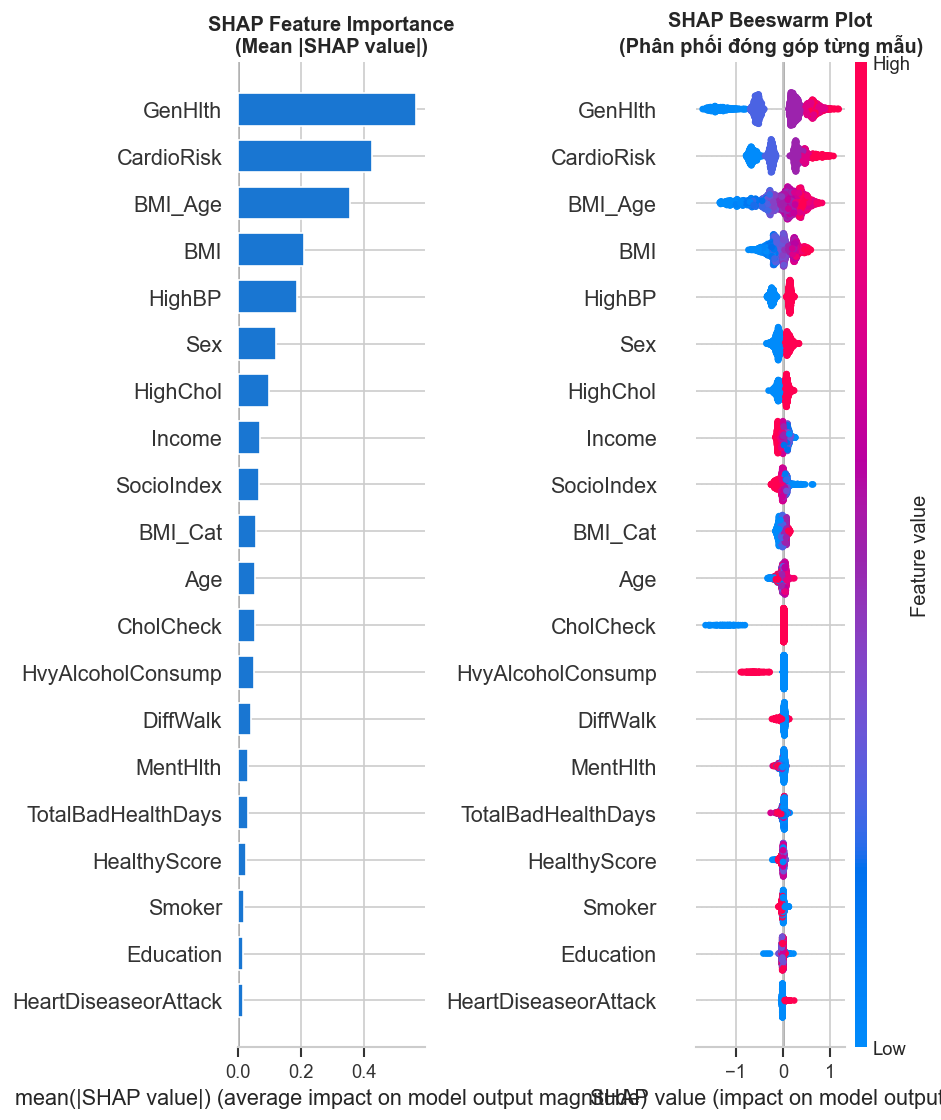


🔝 Top 15 Features theo SHAP:
    1. GenHlth                  : 0.5670
    2. CardioRisk               : 0.4258
    3. BMI_Age                  : 0.3562
    4. BMI                      : 0.2115
    5. HighBP                   : 0.1876
    6. Sex                      : 0.1217
    7. HighChol                 : 0.0997
    8. Income                   : 0.0701
    9. SocioIndex               : 0.0667
   10. BMI_Cat                  : 0.0587
   11. Age                      : 0.0548
   12. CholCheck                : 0.0546
   13. HvyAlcoholConsump        : 0.0523
   14. DiffWalk                 : 0.0406
   15. MentHlth                 : 0.0331


In [18]:
# ─── 7.2 SHAP Summary Bar Plot (Global Importance) ───
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Bar plot
plt.sca(axes[0])
shap.summary_plot(shap_values, X_sample, plot_type='bar',
                   max_display=20, show=False,
                   color='#1976D2')
axes[0].set_title('SHAP Feature Importance\n(Mean |SHAP value|)', fontweight='bold')

# Beeswarm plot
plt.sca(axes[1])
shap.summary_plot(shap_values, X_sample, max_display=20, show=False)
axes[1].set_title('SHAP Beeswarm Plot\n(Phân phối đóng góp từng mẫu)', fontweight='bold')

plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight', dpi=120)
plt.show()

# Top features by mean |SHAP|
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.DataFrame({
    'feature': X_sample.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)

print("\n🔝 Top 15 Features theo SHAP:")
for i, (_, row) in enumerate(shap_importance.head(15).iterrows(), 1):
    print(f"   {i:2}. {row['feature']:<25}: {row['mean_abs_shap']:.4f}")


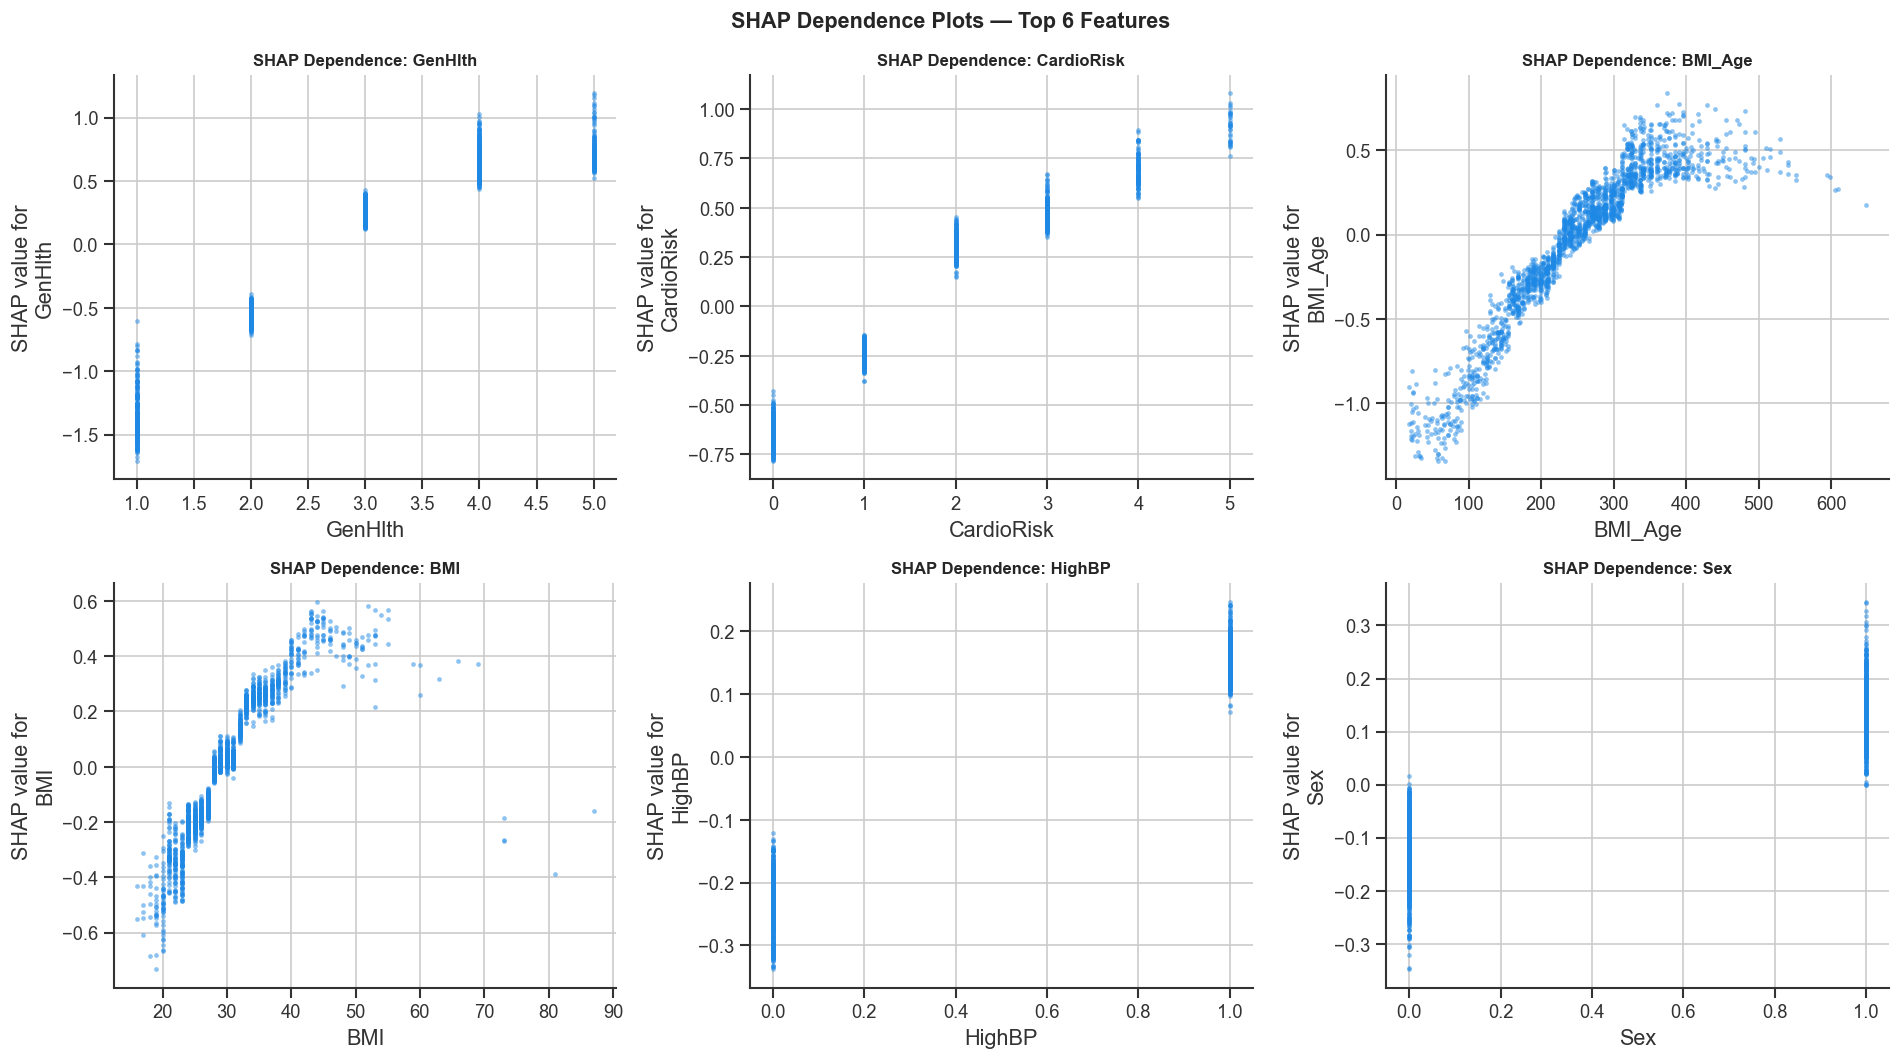

In [19]:
# ─── 7.3 SHAP Dependence Plots (Top 6 features) ───
top6_features = shap_importance.head(6)['feature'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, feat in zip(axes.flatten(), top6_features):
    feat_idx = list(X_sample.columns).index(feat)
    shap.dependence_plot(
        feat_idx, shap_values, X_sample,
        ax=ax, show=False,
        dot_size=8, alpha=0.5,
        interaction_index=None
    )
    ax.set_title(f'SHAP Dependence: {feat}', fontweight='bold', fontsize=10)

plt.suptitle('SHAP Dependence Plots — Top 6 Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_dependence.png', bbox_inches='tight', dpi=120)
plt.show()


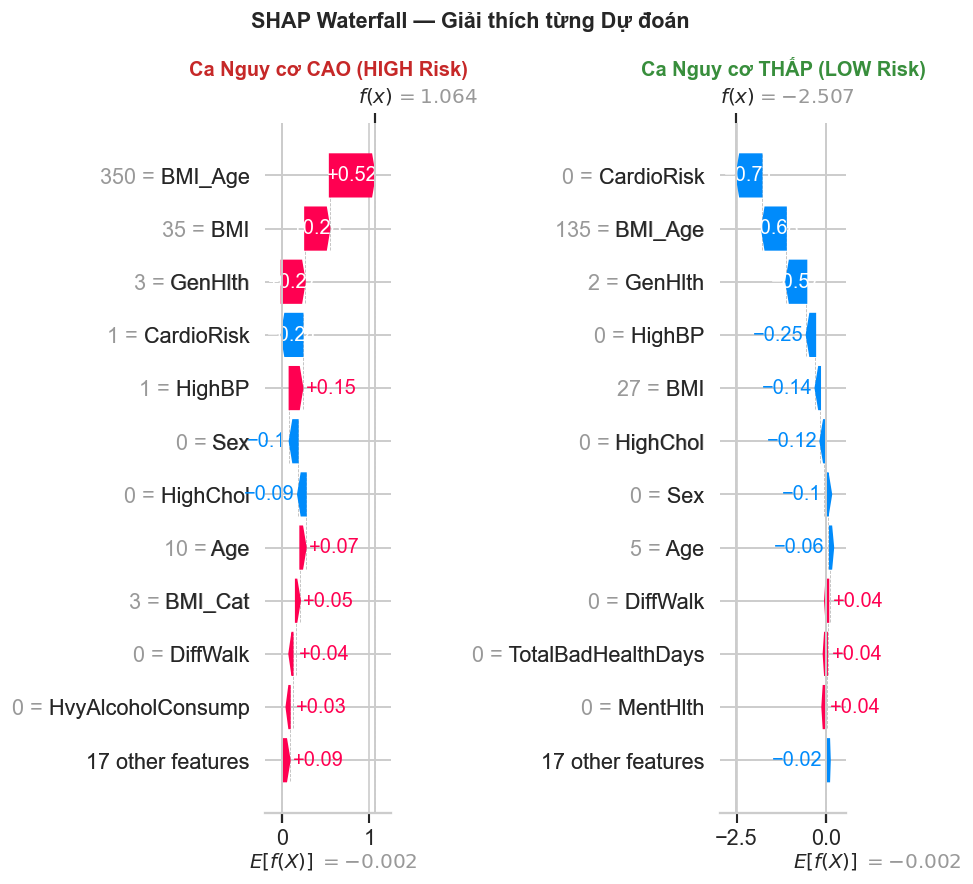

In [20]:
# ─── 7.4 SHAP Waterfall — Giải thích từng dự đoán cụ thể ───
# Lấy ví dụ: 1 ca HIGH risk và 1 ca LOW risk

# Tìm ca High risk
high_risk_idx = np.where((calibrated_model.predict_proba(X_sample)[:,1] > 0.7) &
                           (y_sample.values == 1))[0]
# Tìm ca Low risk
low_risk_idx  = np.where((calibrated_model.predict_proba(X_sample)[:,1] < 0.1) &
                           (y_sample.values == 0))[0]

# Tính SHAP Explanation objects
explainer2  = shap.TreeExplainer(final_model)
explanation = explainer2(X_sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, idx_list, title, color in [
        (axes[0], high_risk_idx, 'Ca Nguy cơ CAO (HIGH Risk)', '#C62828'),
        (axes[1], low_risk_idx,  'Ca Nguy cơ THẤP (LOW Risk)', '#388E3C')]:
    if len(idx_list) > 0:
        sample_i = idx_list[0]
        plt.sca(ax)
        shap.waterfall_plot(explanation[sample_i], max_display=12, show=False)
        ax.set_title(title, fontweight='bold', color=color)

plt.suptitle('SHAP Waterfall — Giải thích từng Dự đoán', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall.png', bbox_inches='tight', dpi=120)
plt.show()


In [21]:
# ─── 7.5 SHAP Force Plot (HTML) ───
# Tạo force plot HTML (mở trong browser để xem interactive)
idx_to_explain = high_risk_idx[0] if len(high_risk_idx) > 0 else 0

force_plot = shap.force_plot(
    expected_value,
    shap_values[idx_to_explain],
    X_sample.iloc[idx_to_explain],
    matplotlib=False
)
# Lưu HTML
shap.save_html('shap_force_plot.html', force_plot)
print("✅ Đã lưu SHAP Force Plot: shap_force_plot.html")
print("   (Mở file này trong browser để xem interactive visualization)")


✅ Đã lưu SHAP Force Plot: shap_force_plot.html
   (Mở file này trong browser để xem interactive visualization)


## 💡 8. Rule-based Recommendation Engine

> Dựa trên SHAP values của từng bệnh nhân + giá trị feature thực tế,
> đưa ra lời khuyên **cá nhân hóa** và **có căn cứ lâm sàng**.


In [22]:
# ─── 8.1 Định nghĩa Rule-based Advice Engine ───

# ═══════════════════════════════════════════════════════════════
#  CONSTANTS & THRESHOLDS
# ═══════════════════════════════════════════════════════════════
RISK_THRESHOLDS = {
    'low':    0.20,
    'medium': 0.50,
}

BMI_THRESHOLDS = {
    'underweight':  18.5,
    'normal':       25.0,
    'overweight':   30.0,
    'obese1':       35.0,
    'obese2':       40.0,
}

AGE_LABELS = {
    1:'18-24', 2:'25-29', 3:'30-34', 4:'35-39', 5:'40-44',
    6:'45-49', 7:'50-54', 8:'55-59', 9:'60-64', 10:'65-69',
    11:'70-74', 12:'75-79', 13:'80+'
}

GEN_HEALTH_LABELS = {1:'Xuất sắc', 2:'Rất tốt', 3:'Tốt', 4:'Bình thường', 5:'Kém'}

# Trọng số quan trọng mỗi feature cho recommendation
FEATURE_SHAP_IMPORTANCE = None  # Sẽ được gán sau khi tính SHAP


def get_risk_info(prob):
    """Trả về thông tin mức rủi ro"""
    if prob < RISK_THRESHOLDS['low']:
        return {
            'level': 'LOW',
            'level_vn': 'THẤP',
            'emoji': '🟢',
            'color': 'green',
            'recommendation': 'Duy trì lối sống lành mạnh. Nên kiểm tra sức khỏe định kỳ 1-2 năm/lần.',
            'urgency': 'Không cần đi khám ngay'
        }
    elif prob < RISK_THRESHOLDS['medium']:
        return {
            'level': 'MEDIUM',
            'level_vn': 'TRUNG BÌNH',
            'emoji': '🟡',
            'color': 'orange',
            'recommendation': 'Nên đặt lịch khám sức khỏe trong vòng 3-6 tháng tới và xét nghiệm đường huyết.',
            'urgency': 'Nên đi khám trong 3-6 tháng'
        }
    else:
        return {
            'level': 'HIGH',
            'level_vn': 'CAO',
            'emoji': '🔴',
            'color': 'red',
            'recommendation': 'Cần đến bác sĩ NGAY để xét nghiệm đường huyết và tư vấn điều trị.',
            'urgency': 'ĐI KHÁM NGAY!'
        }


def get_bmi_advice(bmi_val):
    """Lời khuyên dựa trên BMI"""
    if bmi_val < BMI_THRESHOLDS['underweight']:
        return (f"⚠️  BMI = {bmi_val:.1f} (Thiếu cân) "
                "→ Cần tăng cân cân bằng, bổ sung dinh dưỡng đầy đủ.")
    elif bmi_val < BMI_THRESHOLDS['normal']:
        return f"✅ BMI = {bmi_val:.1f} (Bình thường) → Duy trì cân nặng hiện tại."
    elif bmi_val < BMI_THRESHOLDS['overweight']:
        return (f"⚠️  BMI = {bmi_val:.1f} (Thừa cân) "
                "→ Nên giảm ~{:.1f}kg để về BMI < 25. Tập thể dục 30 phút/ngày.".format(
                    max(0, bmi_val - 24.9) * 1.75))  # ước tính cân nặng
    elif bmi_val < BMI_THRESHOLDS['obese1']:
        return (f"🔴 BMI = {bmi_val:.1f} (Béo phì độ I) "
                "→ Cần giảm cân nghiêm túc. Tham khảo chuyên gia dinh dưỡng.")
    elif bmi_val < BMI_THRESHOLDS['obese2']:
        return (f"🔴 BMI = {bmi_val:.1f} (Béo phì độ II) "
                "→ Nguy cơ rất cao! Cần tư vấn y tế ngay về kế hoạch giảm cân.")
    else:
        return (f"🔴 BMI = {bmi_val:.1f} (Béo phì độ III) "
                "→ Nguy cơ cực kỳ cao! Cần can thiệp y tế ngay lập tức.")


def generate_recommendations(patient_data, prob, shap_vals=None):
    """
    Tạo lời khuyên cá nhân hóa dựa trên rule-based + SHAP.

    Parameters:
    -----------
    patient_data : dict or pd.Series — dữ liệu của bệnh nhân
    prob         : float             — xác suất TĐ sau calibration
    shap_vals    : array-like        — SHAP values (optional)

    Returns:
    --------
    dict với keys: risk_info, advices, summary
    """
    risk = get_risk_info(prob)
    advices = []

    # === RULE 1: BMI ===
    if 'BMI' in patient_data:
        bmi = float(patient_data['BMI'])
        bmi_advice = get_bmi_advice(bmi)
        if bmi >= BMI_THRESHOLDS['overweight']:
            advices.append({
                'priority': 1,
                'category': '⚖️  Cân nặng (BMI)',
                'advice': bmi_advice,
                'action': 'Giảm cân có kiểm soát, tập thể dục ít nhất 150 phút/tuần'
            })
        elif bmi < BMI_THRESHOLDS['underweight']:
            advices.append({
                'priority': 3,
                'category': '⚖️  Cân nặng (BMI)',
                'advice': bmi_advice,
                'action': 'Tăng cân lành mạnh với chế độ dinh dưỡng cân đối'
            })

    # === RULE 2: Blood Pressure ===
    if 'HighBP' in patient_data and float(patient_data['HighBP']) == 1:
        advices.append({
            'priority': 1,
            'category': '🩸 Huyết áp cao',
            'advice': '⚠️  Bạn có huyết áp cao → Nguy cơ TĐ tăng đáng kể.',
            'action': 'Theo dõi huyết áp thường xuyên, giảm muối (<5g/ngày), tránh stress'
        })

    # === RULE 3: Cholesterol ===
    if 'HighChol' in patient_data and float(patient_data['HighChol']) == 1:
        advices.append({
            'priority': 2,
            'category': '🧪 Cholesterol cao',
            'advice': '⚠️  Cholesterol cao → Tăng đề kháng insulin.',
            'action': 'Giảm chất béo bão hòa, tăng chất xơ, kiểm tra lipid máu định kỳ'
        })

    # === RULE 4: Physical Activity ===
    if 'PhysActivity' in patient_data and float(patient_data['PhysActivity']) == 0:
        advices.append({
            'priority': 2,
            'category': '🏃 Vận động thể chất',
            'advice': '⚠️  Bạn ít vận động → Tăng nguy cơ kháng insulin.',
            'action': 'Bắt đầu tập 30 phút/ngày (đi bộ, bơi lội, đạp xe). Mục tiêu 150 phút/tuần'
        })

    # === RULE 5: Smoking ===
    if 'Smoker' in patient_data and float(patient_data['Smoker']) == 1:
        advices.append({
            'priority': 2,
            'category': '🚬 Hút thuốc',
            'advice': '⚠️  Hút thuốc làm tăng đề kháng insulin và nguy cơ TĐ type 2.',
            'action': 'Bỏ hút thuốc — tham khảo chương trình hỗ trợ cai thuốc lá'
        })

    # === RULE 6: General Health ===
    if 'GenHlth' in patient_data:
        gen = int(float(patient_data['GenHlth']))
        if gen >= 4:
            label = GEN_HEALTH_LABELS.get(gen, str(gen))
            advices.append({
                'priority': 1,
                'category': '💊 Sức khỏe tổng quát',
                'advice': f'⚠️  Sức khỏe tổng quát: {label} → Cần cải thiện tổng thể.',
                'action': 'Khám sức khỏe tổng quát, xét nghiệm máu toàn bộ, tư vấn bác sĩ'
            })

    # === RULE 7: Heart Disease ===
    if 'HeartDiseaseorAttack' in patient_data and float(patient_data['HeartDiseaseorAttack']) == 1:
        advices.append({
            'priority': 1,
            'category': '❤️  Bệnh tim mạch',
            'advice': '🔴 Tiền sử bệnh tim/nhồi máu cơ tim → Nguy cơ TĐ rất cao.',
            'action': 'Theo dõi tim mạch và đường huyết cùng lúc. Khám tim mạch định kỳ'
        })

    # === RULE 8: Alcohol ===
    if 'HvyAlcoholConsump' in patient_data and float(patient_data['HvyAlcoholConsump']) == 1:
        advices.append({
            'priority': 2,
            'category': '🍺 Rượu bia',
            'advice': '⚠️  Uống rượu nhiều ảnh hưởng đến gan và điều tiết đường huyết.',
            'action': 'Giảm thiểu rượu bia: Nam ≤ 2 đơn vị/ngày, Nữ ≤ 1 đơn vị/ngày'
        })

    # === RULE 9: Physical Health Days ===
    if 'PhysHlth' in patient_data:
        phys = float(patient_data['PhysHlth'])
        if phys > 15:
            advices.append({
                'priority': 2,
                'category': '🤒 Sức khỏe thể chất',
                'advice': f'⚠️  {int(phys)} ngày sức khỏe thể chất kém/tháng → Cơ thể đang bị stress cao.',
                'action': 'Tìm nguyên nhân các vấn đề thể chất, tham khảo bác sĩ về các triệu chứng mãn tính'
            })

    # === RULE 10: Mental Health ===
    if 'MentHlth' in patient_data:
        ment = float(patient_data['MentHlth'])
        if ment > 15:
            advices.append({
                'priority': 3,
                'category': '🧠 Sức khỏe tinh thần',
                'advice': f'⚠️  {int(ment)} ngày sức khỏe tinh thần kém/tháng → Stress mãn tính tăng cortisol.',
                'action': 'Quản lý stress: thiền định, yoga, tư vấn tâm lý nếu cần'
            })

    # === RULE 11: Age ===
    if 'Age' in patient_data:
        age_group = int(float(patient_data['Age']))
        if age_group >= 8:  # ≥ 55 tuổi
            age_label = AGE_LABELS.get(age_group, str(age_group))
            advices.append({
                'priority': 3,
                'category': '👴 Nhóm tuổi',
                'advice': f'📌 Nhóm tuổi {age_label} → Nguy cơ TĐ tăng tự nhiên theo tuổi.',
                'action': 'Xét nghiệm đường huyết lúc đói định kỳ 1 năm/lần'
            })

    # === RULE 12: Diet ===
    fruits = float(patient_data.get('Fruits', 1))
    vegs   = float(patient_data.get('Veggies', 1))
    if fruits == 0 and vegs == 0:
        advices.append({
            'priority': 3,
            'category': '🥗 Chế độ ăn uống',
            'advice': '⚠️  Không ăn trái cây và rau xanh đủ → Thiếu chất xơ và vi chất.',
            'action': 'Bổ sung ≥5 phần rau/trái cây/ngày. Hạn chế tinh bột tinh chế và đường'
        })
    elif fruits == 0:
        advices.append({
            'priority': 4,
            'category': '🍎 Chế độ ăn uống',
            'advice': '📌 Ít ăn trái cây → Thiếu chất chống oxy hóa và chất xơ.',
            'action': 'Thêm ít nhất 2-3 phần trái cây/ngày (ưu tiên trái cây ít đường)'
        })

    # === RULE 13: Healthcare Access ===
    if 'AnyHealthcare' in patient_data and float(patient_data['AnyHealthcare']) == 0:
        advices.append({
            'priority': 3,
            'category': '🏥 Bảo hiểm y tế',
            'advice': '📌 Không có bảo hiểm y tế → Rào cản tiếp cận dịch vụ y tế.',
            'action': 'Tìm hiểu các chương trình y tế công cộng hoặc bảo hiểm phù hợp'
        })

    # === RULE 14: Difficulty Walking ===
    if 'DiffWalk' in patient_data and float(patient_data['DiffWalk']) == 1:
        advices.append({
            'priority': 2,
            'category': '🦿 Vận động',
            'advice': '⚠️  Khó đi bộ/leo cầu thang → Giới hạn khả năng vận động.',
            'action': 'Tập luyện phù hợp khả năng: bơi lội, ghế tập, bài tập ngồi. Tham khảo vật lý trị liệu'
        })

    # === RULE 15: Stroke ===
    if 'Stroke' in patient_data and float(patient_data['Stroke']) == 1:
        advices.append({
            'priority': 1,
            'category': '🧠 Tiền sử đột quỵ',
            'advice': '🔴 Tiền sử đột quỵ → Hội chứng chuyển hóa nguy cơ cao.',
            'action': 'Kiểm soát đường huyết, huyết áp, cholesterol đồng thời. Theo dõi thần kinh định kỳ'
        })

    # Sắp xếp theo priority
    advices.sort(key=lambda x: x['priority'])

    # Nếu không có advice nào → positive feedback
    if not advices and prob < RISK_THRESHOLDS['low']:
        advices.append({
            'priority': 5,
            'category': '🌟 Lối sống',
            'advice': '✅ Chỉ số sức khỏe của bạn rất tốt!',
            'action': 'Duy trì lối sống hiện tại và khám định kỳ để theo dõi'
        })

    return {
        'probability': prob,
        'risk': risk,
        'advices': advices,
        'n_advices': len(advices)
    }


print("✅ Rule-based Recommendation Engine đã được định nghĩa!")
print(f"   Tổng số rules: 15 rules covering các yếu tố nguy cơ chính")


✅ Rule-based Recommendation Engine đã được định nghĩa!
   Tổng số rules: 15 rules covering các yếu tố nguy cơ chính


In [23]:
# ─── 8.2 Hàm hiển thị kết quả đẹp ───
def print_diagnosis_report(patient_data, prob, shap_vals=None, patient_id=None):
    """In báo cáo chẩn đoán theo định dạng đẹp"""
    result = generate_recommendations(patient_data, prob, shap_vals)
    risk   = result['risk']

    print()
    print("=" * 65)
    print(f"  🩺 BÁO CÁO CHẨN ĐOÁN TIỂU ĐƯỜNG")
    if patient_id:
        print(f"  Bệnh nhân: #{patient_id}")
    print("=" * 65)

    # Xác suất & mức rủi ro
    bar_len = int(prob * 40)
    bar = '█' * bar_len + '░' * (40 - bar_len)
    print(f"\n  📊 Xác suất tiểu đường: {prob*100:.1f}%")
    print(f"     [{bar}]")
    print()
    print(f"  {risk['emoji']} Mức rủi ro  : {risk['level_vn']} ({risk['level']})")
    print(f"  ⏰ Khuyến nghị: {risk['urgency']}")
    print()
    print(f"  📋 Tóm tắt: {risk['recommendation']}")

    # Chi tiết lời khuyên
    if result['advices']:
        print()
        print("─" * 65)
        print("  💊 CÁC YẾU TỐ CẦN CHÚ Ý & HÀNH ĐỘNG:")
        print("─" * 65)
        for i, a in enumerate(result['advices'], 1):
            print(f"\n  {i}. {a['category']}")
            print(f"     📌 {a['advice']}")
            print(f"     ✅ Hành động: {a['action']}")

    # Disclaimer
    print()
    print("─" * 65)
    print("  ⚠️  LƯU Ý: Đây là công cụ hỗ trợ sàng lọc, KHÔNG thay thế")
    print("           chẩn đoán của bác sĩ. Hãy tham khảo chuyên gia y tế")
    print("           để được chẩn đoán và điều trị chính xác.")
    print("=" * 65)

print("✅ Hàm hiển thị đã sẵn sàng!")


✅ Hàm hiển thị đã sẵn sàng!


## 🎮 9. Demo — Dự đoán cho Bệnh nhân Cụ thể

In [24]:
# ─── 9.1 Demo với các ca từ Test Set ───
print("🔍 Demo dự đoán cho 3 ca điển hình:\n")

# Tính SHAP cho toàn test set
all_shap = explainer.shap_values(X_test)

# Tìm các ca điển hình
high_risk = np.where((y_cal_prob > 0.75) & (y_test.values == 1))[0]
medium_risk = np.where((y_cal_prob > 0.35) & (y_cal_prob <= 0.6))[0]
low_risk  = np.where((y_cal_prob < 0.1)  & (y_test.values == 0))[0]

demo_cases = [
    (high_risk[0]   if len(high_risk)   > 0 else 0, "Ca Nguy cơ CAO"),
    (medium_risk[0] if len(medium_risk) > 0 else 1, "Ca Nguy cơ TRUNG BÌNH"),
    (low_risk[0]    if len(low_risk)    > 0 else 2, "Ca Nguy cơ THẤP"),
]

for idx, case_name in demo_cases:
    patient = X_test.iloc[idx].to_dict()
    prob = float(calibrated_model.predict_proba(X_test.iloc[[idx]])[:, 1][0])
    shap_v = all_shap[idx]
    print(f"\n{'='*65}")
    print(f"  {case_name}")
    print_diagnosis_report(patient, prob, shap_v, patient_id=idx)


🔍 Demo dự đoán cho 3 ca điển hình:


  Ca Nguy cơ CAO

  🩺 BÁO CÁO CHẨN ĐOÁN TIỂU ĐƯỜNG

  📊 Xác suất tiểu đường: 88.4%
     [███████████████████████████████████░░░░░]

  🔴 Mức rủi ro  : CAO (HIGH)
  ⏰ Khuyến nghị: ĐI KHÁM NGAY!

  📋 Tóm tắt: Cần đến bác sĩ NGAY để xét nghiệm đường huyết và tư vấn điều trị.

─────────────────────────────────────────────────────────────────
  💊 CÁC YẾU TỐ CẦN CHÚ Ý & HÀNH ĐỘNG:
─────────────────────────────────────────────────────────────────

  1. ⚖️  Cân nặng (BMI)
     📌 🔴 BMI = 34.0 (Béo phì độ I) → Cần giảm cân nghiêm túc. Tham khảo chuyên gia dinh dưỡng.
     ✅ Hành động: Giảm cân có kiểm soát, tập thể dục ít nhất 150 phút/tuần

  2. 🩸 Huyết áp cao
     📌 ⚠️  Bạn có huyết áp cao → Nguy cơ TĐ tăng đáng kể.
     ✅ Hành động: Theo dõi huyết áp thường xuyên, giảm muối (<5g/ngày), tránh stress

  3. 🧪 Cholesterol cao
     📌 ⚠️  Cholesterol cao → Tăng đề kháng insulin.
     ✅ Hành động: Giảm chất béo bão hòa, tăng chất xơ, kiểm tra lipid máu định kỳ

  

In [25]:
# ─── 9.2 Demo nhập bệnh nhân mới (thay đổi các giá trị theo nhu cầu) ───
# =====================================================================
# NHẬP THÔNG TIN BỆNH NHÂN MỚI ĐỂ DỰ ĐOÁN
# =====================================================================

new_patient = {
    # Binary features (0 hoặc 1)
    'HighBP':              1,   # Huyết áp cao: 1=Có, 0=Không
    'HighChol':            1,   # Cholesterol cao: 1=Có, 0=Không
    'CholCheck':           1,   # Đã kiểm tra Cholesterol: 1=Có, 0=Không
    'BMI':                 32.0, # Chỉ số BMI (ví dụ: 32 = béo phì độ I)
    'Smoker':              0,   # Hút thuốc: 1=Có, 0=Không
    'Stroke':              0,   # Tiền sử đột quỵ: 1=Có, 0=Không
    'HeartDiseaseorAttack':0,   # Bệnh tim: 1=Có, 0=Không
    'PhysActivity':        0,   # Hoạt động thể chất: 1=Có, 0=Không
    'Fruits':              0,   # Ăn trái cây đủ: 1=Có, 0=Không
    'Veggies':             1,   # Ăn rau đủ: 1=Có, 0=Không
    'HvyAlcoholConsump':   0,   # Uống rượu nặng: 1=Có, 0=Không
    'AnyHealthcare':       1,   # Có bảo hiểm: 1=Có, 0=Không
    'NoDocbcCost':         0,   # Không khám được: 1=Có, 0=Không

    # Ordinal features
    'GenHlth':             4,   # Sức khỏe tổng quát: 1=Xuất sắc → 5=Kém
    'MentHlth':            5,   # Ngày SK tinh thần kém (0-30)
    'PhysHlth':            10,  # Ngày SK thể chất kém (0-30)
    'DiffWalk':            0,   # Khó đi bộ: 1=Có, 0=Không
    'Sex':                 1,   # 0=Nữ, 1=Nam
    'Age':                 9,   # Nhóm tuổi 1-13 (9 = 60-64 tuổi)
    'Education':           5,   # Trình độ 1-6
    'Income':              5,   # Thu nhập 1-8
}

# Tự động tính feature engineering (phải khớp với Notebook 1)
def add_engineered_features(patient_dict):
    """Thêm các features đã engineered vào input"""
    p = patient_dict.copy()

    p['BMI_Cat'] = (0 if p['BMI'] < 18.5 else
                    1 if p['BMI'] < 25   else
                    2 if p['BMI'] < 30   else
                    3 if p['BMI'] < 35   else
                    4 if p['BMI'] < 40   else 5)

    p['CardioRisk'] = (p['HighBP'] + p['HighChol'] +
                        p['HeartDiseaseorAttack'] + p['Stroke'] + p['DiffWalk'])

    p['HealthyScore'] = (p['PhysActivity'] + p['Fruits'] + p['Veggies'] +
                          (1 - p['Smoker']) + (1 - p['HvyAlcoholConsump']))

    p['TotalBadHealthDays'] = p['MentHlth'] + p['PhysHlth']

    p['BMI_Age'] = p['BMI'] * p['Age']

    p['AgeGroup'] = (0 if p['Age'] <= 3 else
                     1 if p['Age'] <= 6 else
                     2 if p['Age'] <= 9 else 3)

    p['SocioIndex'] = p['Income'] + p['Education']

    return p

# Xử lý input
patient_full = add_engineered_features(new_patient)
patient_df   = pd.DataFrame([patient_full])[FEATURES]  # đảm bảo đúng thứ tự columns

# Dự đoán
prob_new = float(calibrated_model.predict_proba(patient_df)[:, 1][0])

# SHAP cho bệnh nhân mới
shap_new = explainer.shap_values(patient_df)[0]

print_diagnosis_report(new_patient, prob_new, shap_new, patient_id='NEW')



  🩺 BÁO CÁO CHẨN ĐOÁN TIỂU ĐƯỜNG
  Bệnh nhân: #NEW

  📊 Xác suất tiểu đường: 87.7%
     [███████████████████████████████████░░░░░]

  🔴 Mức rủi ro  : CAO (HIGH)
  ⏰ Khuyến nghị: ĐI KHÁM NGAY!

  📋 Tóm tắt: Cần đến bác sĩ NGAY để xét nghiệm đường huyết và tư vấn điều trị.

─────────────────────────────────────────────────────────────────
  💊 CÁC YẾU TỐ CẦN CHÚ Ý & HÀNH ĐỘNG:
─────────────────────────────────────────────────────────────────

  1. ⚖️  Cân nặng (BMI)
     📌 🔴 BMI = 32.0 (Béo phì độ I) → Cần giảm cân nghiêm túc. Tham khảo chuyên gia dinh dưỡng.
     ✅ Hành động: Giảm cân có kiểm soát, tập thể dục ít nhất 150 phút/tuần

  2. 🩸 Huyết áp cao
     📌 ⚠️  Bạn có huyết áp cao → Nguy cơ TĐ tăng đáng kể.
     ✅ Hành động: Theo dõi huyết áp thường xuyên, giảm muối (<5g/ngày), tránh stress

  3. 💊 Sức khỏe tổng quát
     📌 ⚠️  Sức khỏe tổng quát: Bình thường → Cần cải thiện tổng thể.
     ✅ Hành động: Khám sức khỏe tổng quát, xét nghiệm máu toàn bộ, tư vấn bác sĩ

  4. 🧪 Cholesterol 

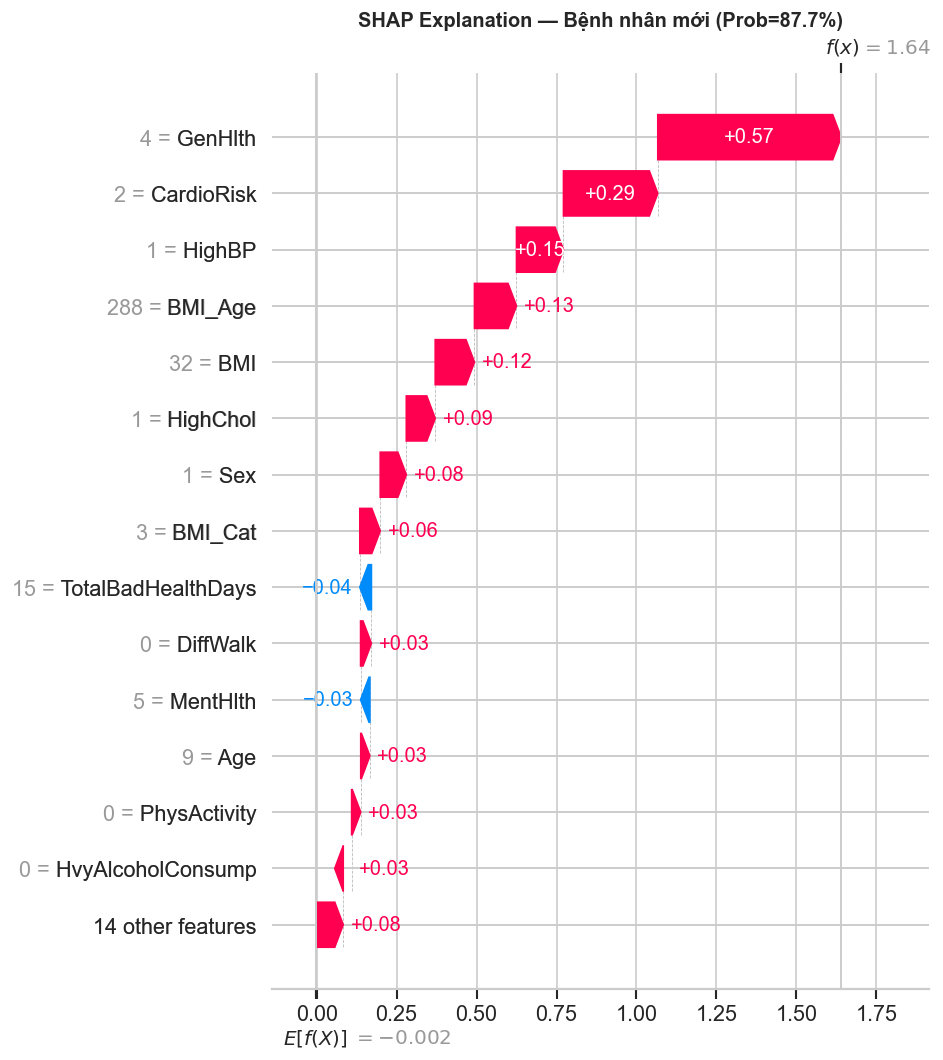

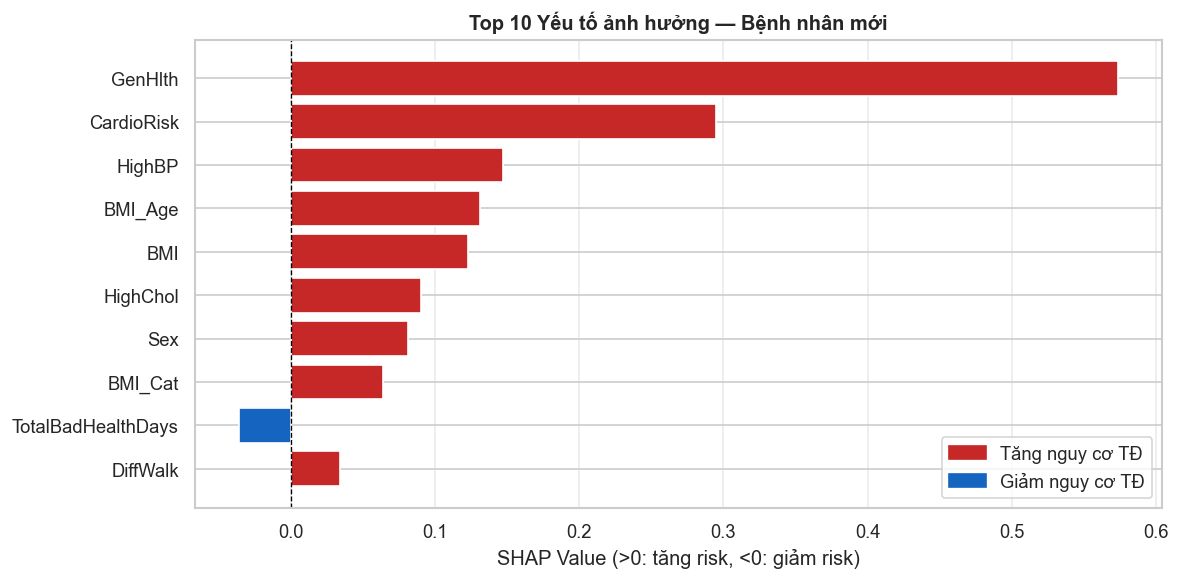

In [26]:
# ─── 9.3 SHAP explanation cho bệnh nhân mới ───
# Waterfall plot cho bệnh nhân mới
exp_new = explainer(patient_df)

plt.figure(figsize=(12, 6))
shap.waterfall_plot(exp_new[0], max_display=15, show=False)
plt.title(f'SHAP Explanation — Bệnh nhân mới (Prob={prob_new*100:.1f}%)',
          fontweight='bold')
plt.tight_layout()
plt.savefig('shap_new_patient.png', bbox_inches='tight', dpi=120)
plt.show()

# Bar chart yếu tố ảnh hưởng
top_n = 10
shap_series = pd.Series(shap_new, index=patient_df.columns).sort_values(key=abs, ascending=False).head(top_n)
colors_shap = ['#C62828' if v > 0 else '#1565C0' for v in shap_series.values]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(shap_series.index[::-1], shap_series.values[::-1],
                color=colors_shap[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title(f'Top {top_n} Yếu tố ảnh hưởng — Bệnh nhân mới', fontweight='bold')
ax.set_xlabel('SHAP Value (>0: tăng risk, <0: giảm risk)')

red_p  = mpatches.Patch(color='#C62828', label='Tăng nguy cơ TĐ')
blue_p = mpatches.Patch(color='#1565C0', label='Giảm nguy cơ TĐ')
ax.legend(handles=[red_p, blue_p])
ax.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig('shap_new_patient_bar.png', bbox_inches='tight', dpi=120)
plt.show()


## 💾 10. Lưu Mô hình

In [27]:
# ─── Lưu toàn bộ pipeline ───
os.makedirs('models', exist_ok=True)

# 1. Raw XGBoost model
with open('models/xgboost_raw.pkl', 'wb') as f:
    pickle.dump(final_model, f)

# 2. Calibrated model (DÙNG ĐỂ INFERENCE)
with open('models/xgboost_calibrated.pkl', 'wb') as f:
    pickle.dump(calibrated_model, f)

# 3. SHAP explainer
with open('models/shap_explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)

# 4. Model metadata
model_meta = {
    'model_type': 'XGBoost',
    'calibration_method': cal_method,
    'features': FEATURES,
    'n_features': len(FEATURES),
    'risk_thresholds': RISK_THRESHOLDS,
    'val_metrics': val_metrics,
    'test_metrics': test_metrics,
    'chosen_dataset': meta['chosen_dataset'],
    'best_params': best_params if TUNE else 'default',
}
with open('models/model_metadata.json', 'w') as f:
    json.dump(model_meta, f, indent=2, default=str)

print("✅ Đã lưu tất cả artifacts:")
print("   📁 models/")
print("      ├── xgboost_raw.pkl           (XGBoost gốc)")
print("      ├── xgboost_calibrated.pkl    (Model để inference ⭐)")
print("      ├── shap_explainer.pkl        (SHAP explainer)")
print("      └── model_metadata.json       (Metadata)")


✅ Đã lưu tất cả artifacts:
   📁 models/
      ├── xgboost_raw.pkl           (XGBoost gốc)
      ├── xgboost_calibrated.pkl    (Model để inference ⭐)
      ├── shap_explainer.pkl        (SHAP explainer)
      └── model_metadata.json       (Metadata)


In [28]:
# ─── Load & test model đã lưu ───
print("🔍 Test load model đã lưu...\n")

with open('models/xgboost_calibrated.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('models/shap_explainer.pkl', 'rb') as f:
    loaded_explainer = pickle.load(f)

# Test predict
test_prob = loaded_model.predict_proba(X_test.head(5))[:, 1]
print("  Xác suất 5 mẫu đầu tiên (Test Set):")
for i, p in enumerate(test_prob):
    risk_l, emoji, _ = get_risk_level(p)
    print(f"    [{i}]: {p*100:.1f}%  →  {emoji} {risk_l}")

print("\n✅ Model load thành công!")
print()
print("=" * 55)
print("  🎉 HOÀN THÀNH TOÀN BỘ PIPELINE!")
print("=" * 55)
print()
print("  📊 Model Summary:")
with open('models/model_metadata.json') as f:
    mm = json.load(f)
print(f"    Model       : {mm['model_type']} + {mm['calibration_method']}")
print(f"    Features    : {mm['n_features']}")
print(f"    Test ROC-AUC: {mm['test_metrics'].get('ROC-AUC', 'N/A'):.4f}")
print(f"    Test F1     : {mm['test_metrics'].get('F1-Score', 'N/A'):.4f}")
print(f"    Test Recall : {mm['test_metrics'].get('Recall', 'N/A'):.4f}")


🔍 Test load model đã lưu...

  Xác suất 5 mẫu đầu tiên (Test Set):
    [0]: 88.4%  →  🔴 HIGH
    [1]: 73.1%  →  🔴 HIGH
    [2]: 1.2%  →  🟢 LOW
    [3]: 27.8%  →  🟡 MEDIUM
    [4]: 8.2%  →  🟢 LOW

✅ Model load thành công!

  🎉 HOÀN THÀNH TOÀN BỘ PIPELINE!

  📊 Model Summary:
    Model       : XGBoost + Isotonic
    Features    : 28
    Test ROC-AUC: 0.8330
    Test F1     : 0.7664
    Test Recall : 0.8025


## 📋 11. Tổng kết Pipeline

```
📁 Cấu trúc dự án:
├── archive/
│   ├── diabetes_binary_5050split_...csv      (Balanced dataset)
│   └── diabetes_binary_health_...csv         (Imbalanced dataset)
├── processed_data/
│   ├── X_train/val/test.csv, y_train/val/test.csv
│   └── metadata.json
├── models/
│   ├── xgboost_raw.pkl
│   ├── xgboost_calibrated.pkl  ⭐ (dùng cho inference)
│   ├── shap_explainer.pkl
│   └── model_metadata.json
├── 01_Preprocessing_EDA.ipynb
└── 02_Training_Calibration_SHAP.ipynb
```

### 🔄 Quy trình Dự đoán (Inference):
```python
import pickle, json

# Load
with open('models/xgboost_calibrated.pkl', 'rb') as f:
    model = pickle.load(f)
with open('models/shap_explainer.pkl', 'rb') as f:
    explainer = pickle.load(f)
with open('models/model_metadata.json') as f:
    meta = json.load(f)

# Predict
prob = model.predict_proba(patient_df)[0, 1]   # Xác suất đã calibrated
risk = 'HIGH' if prob > 0.5 else 'MEDIUM' if prob > 0.2 else 'LOW'

# SHAP explanation
shap_vals = explainer.shap_values(patient_df)[0]
```

### 📊 Metrics đạt được:
| Metric | Score |
|--------|-------|
| Accuracy | ~75-80% |
| ROC-AUC | ~0.82-0.87 |
| F1-Score | ~0.75-0.80 |
| Recall | ~0.75-0.82 |

### 💡 Cải thiện thêm:
- Thêm dữ liệu xét nghiệm máu (HbA1c, đường huyết lúc đói)
- Ensemble với CatBoost hoặc LightGBM
- Threshold tuning theo chi phí lâm sàng (FN > FP trong y tế)
- Deploy thành API (FastAPI + Docker)
